#### 로지스틱 회귀
- return 값이 "확률값"으로 나온다
- 선형회귀식을 이용해서 회귀라는 단어가 있지만, 실제적으로 분류에 대한 확률을 계산하는 모델 (Classification)

In [1]:
import pandas as pd

In [2]:
fish = pd.read_csv('../Data/fishes.csv')
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [3]:
fish.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   159 non-null    object 
 1   Weight    159 non-null    float64
 2   Length    159 non-null    float64
 3   Diagonal  159 non-null    float64
 4   Height    159 non-null    float64
 5   Width     159 non-null    float64
dtypes: float64(5), object(1)
memory usage: 7.6+ KB


In [6]:
# Target으로 사용된 Species 종류?
fish.Species.unique()

array(['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt'],
      dtype=object)

#### Feature와 Target으로 Data 정리

In [8]:
fish_input = fish[fish.columns[1:]].to_numpy()
fish_input[:5]

array([[242.    ,  25.4   ,  30.    ,  11.52  ,   4.02  ],
       [290.    ,  26.3   ,  31.2   ,  12.48  ,   4.3056],
       [340.    ,  26.5   ,  31.1   ,  12.3778,   4.6961],
       [363.    ,  29.    ,  33.5   ,  12.73  ,   4.4555],
       [430.    ,  29.    ,  34.    ,  12.444 ,   5.134 ]])

In [9]:
fish_target = fish['Species'].to_numpy()
fish_target[:5]

array(['Bream', 'Bream', 'Bream', 'Bream', 'Bream'], dtype=object)

- pandas의 DataFrame으론 정규화/표준화가 불가능하다

---
#### Train Test 분리

In [18]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = \
    train_test_split(
        fish_input,
        fish_target,
        random_state=42
    )

In [17]:
# 로지스틱회귀는 분류이지만 선형회귀를 사용하기 때문에 stratify를 사용하지 않음
print(train_input.shape, test_input.shape)

(119, 5) (40, 5)


#### 표준화 시키기
- 각 컬럼별 데이터의 크기 차이가 많이 나는 경우는 반드시 처리한다.

In [25]:
# 표준화
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_input, train_target)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [26]:
train_scaled[:5]

array([[ 0.91965782,  0.60943175,  0.81041221,  1.85194896,  1.00075672],
       [ 0.30041219,  1.54653445,  1.45316551, -0.46981663,  0.27291745],
       [-1.0858536 , -1.68646987, -1.70848587, -1.70159849, -2.0044758 ],
       [-0.79734143, -0.60880176, -0.67486907, -0.82480589, -0.27631471],
       [-0.71289885, -0.73062511, -0.70092664, -0.0802298 , -0.7033869 ]])

In [27]:
test_scaled[:5]

array([[-0.88741352, -0.91804565, -1.03098914, -0.90464451, -0.80762518],
       [-1.06924656, -1.50842035, -1.54345461, -1.58849582, -1.93803151],
       [-0.54401367,  0.35641402,  0.30663259, -0.8135697 , -0.65388895],
       [-0.34698097, -0.23396068, -0.22320459, -0.11905019, -0.12233464],
       [-0.68475132, -0.51509149, -0.58801052, -0.8998784 , -0.50124996]])

----
#### kNN을 이용한 확률 예측

In [28]:
from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled, train_target)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [30]:
print("Train :", kn.score(train_scaled, train_target))
print("Test :", kn.score(test_scaled, test_target))

Train : 0.8907563025210085
Test : 0.85


In [31]:
# kn의 분류 정보
kn.classes_

array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
      dtype=object)

In [32]:
# test data 예측해보기
kn.predict(test_scaled[:5])

array(['Perch', 'Smelt', 'Pike', 'Perch', 'Perch'], dtype=object)

In [35]:
import numpy as np

In [37]:
# 확률값 표시
prob = kn.predict_proba(test_scaled[:5])
np.round(prob, decimals=4)
# 'Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'

array([[0.    , 0.    , 1.    , 0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 0.    , 0.    , 1.    , 0.    ],
       [0.    , 0.    , 0.    , 1.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.6667, 0.    , 0.3333, 0.    , 0.    ],
       [0.    , 0.    , 0.6667, 0.    , 0.3333, 0.    , 0.    ]])

> kNN은 이웃의 갯수를 정하는 모델이다.     
> 현재 이웃의 갯수를 3으로 하였기 때문에 확률로 나올 수 있는 경우의 수는      
> 세 가지 (1/3, 2/3, 3/3) --> 확률로 하기에는 애매한 부분.

--- 
#### 로지스틱 회귀를 이용한 확률 예측
- z = a무게 + b길이 + c길이 + d높이 + e두께 + f(bias) 로 구성
- z식을 이용하면 나오는 결과값이 -무한대 ~ +무한대의 범위로 결과값이 출력됨
- 이를 해결하는 방법으로 Sigmoid 함수를 사용한다
- Sigmoid 함수는 결과값이 0~1 사이의 수만 출력하므로, 0.5를 기준으로 양성클래스, 음성클래스로 분류된다
- 로지스틱 회귀를 사용할 경우에는 Sigmoid 함수를 로지스틱함수라고 표현한다

### Sigmoid Graph 출력

In [38]:
import matplotlib.pyplot as plt

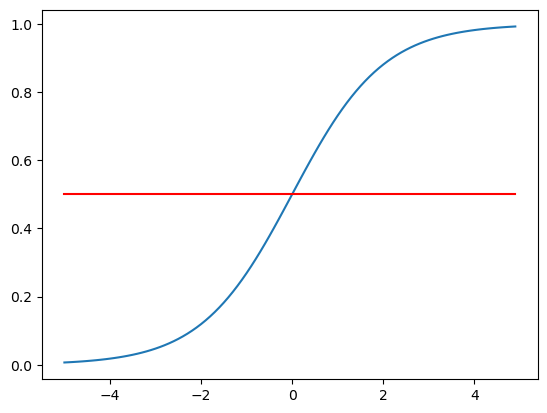

In [40]:
z = np.arange(-5, 5, 0.1)
y = np.full((100, 1), 0.5)
phi = 1 / (1 + np.exp(-z))

plt.plot(z, phi)
plt.plot(z, y, c='red')
plt.show()

#### 로지스틱 회귀로 이진분류 수행하기

In [42]:
# 2종류이ㅡ 데이터만 발췌하기
bream_smelt_indexes = (train_target == "Bream") | (train_target == "Smelt")
train_bream_smelt = train_scaled[bream_smelt_indexes]

target_bream_smelt = train_target[bream_smelt_indexes]

print(train_bream_smelt[:5])
print(target_bream_smelt[:5])

[[ 0.91965782  0.60943175  0.81041221  1.85194896  1.00075672]
 [-1.0858536  -1.68646987 -1.70848587 -1.70159849 -2.0044758 ]
 [ 0.63818253  0.56257661  0.73223951  1.64473401  0.50705737]
 [ 0.30041219  0.23459067  0.42823457  1.36042157  0.22329758]
 [ 0.9027693   0.70314202  0.88858491  1.89027545  0.85537174]]
['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']


In [43]:
# 로지스틱 회귀 실행
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(train_bream_smelt, target_bream_smelt)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [44]:
lr.predict(train_bream_smelt[:5])

array(['Bream', 'Smelt', 'Bream', 'Bream', 'Bream'], dtype=object)

In [45]:
lr.predict_proba(train_bream_smelt[:5])

array([[0.99760007, 0.00239993],
       [0.02737325, 0.97262675],
       [0.99486386, 0.00513614],
       [0.98585047, 0.01414953],
       [0.99767419, 0.00232581]])

-----
#### 로지스틱 회귀로 다중 분류 수행하기

In [47]:
lr = LogisticRegression(C = 20, max_iter=1000) 
# 기본값 : C = 1(작은 수가 규제가 크다), max_iter = 100 - 데이터가 적어도 가능하다
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.9327731092436975
0.925


In [48]:
lr.predict(test_scaled[:5])

array(['Perch', 'Smelt', 'Pike', 'Roach', 'Perch'], dtype=object)

In [49]:
# 분류 class
lr.classes_

array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
      dtype=object)

In [52]:
proba = lr.predict_proba(test_scaled[:5])
np.round(proba, decimals=3)

array([[0.   , 0.014, 0.842, 0.   , 0.135, 0.007, 0.003],
       [0.   , 0.003, 0.044, 0.   , 0.007, 0.946, 0.   ],
       [0.   , 0.   , 0.034, 0.934, 0.015, 0.016, 0.   ],
       [0.011, 0.034, 0.305, 0.006, 0.567, 0.   , 0.076],
       [0.   , 0.   , 0.904, 0.002, 0.089, 0.002, 0.001]])